Here we will perform two stage model 
1. Stage 1 for filtering low and high coupling
2. predict coupling based on regression analysis

In [ ]:
# ===============================
# 0. IMPORT LIBRARIES
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

READ FILE

In [ ]:
df = pd.read_csv("../data/808_alpha_shift_dataset.csv")
df.describe()

,Coupling_eV,Diabatic_E1_Ha,Diabatic_E2_Ha,Energy_Gap_eV,Total_Energy_Ha,Overlap_S12,Interlayer_Dist_Ang,FeFe_Dist_Ang,Min_HeavyDist_Ang,Max_HeavyDist_Ang,...,d_lateral,cos_4alpha,sin_4alpha,S12_b3lyp,S12_srsh_singlet,S12_srsh_cation,S12_qchem_truth,J_eht_eV,J_zindo_eV,J_dftb_eV
count,808.000000,808.000000,808.000000,808.000000,808.000000,8.080000e+02,808.000000,808.000000,808.000000,808.000000,...,808.000000,808.000000,808.000000,808.000000,808.000000,808.000000,1.110000e+02,808.000000,7.370000e+02,26.000000
mean,0.016188,-4501.028375,-4501.039243,-0.295710,-9002.067618,2.509655e-03,4.785023,7.470444,4.365817,14.184717,...,4.925187,-0.053262,0.118971,-0.000235,-0.000141,-0.000130,-9.826951e-04,0.000988,3.374867e-02,0.040364
std,0.035875,0.033983,0.036581,0.699445,0.065767,5.683176e-02,1.978907,1.822291,1.195758,2.211613,...,2.840616,0.874491,0.468501,0.007319,0.006698,0.006448,3.625982e-02,0.011732,6.586311e-02,0.088975
min,0.000000,-4501.135401,-4501.138588,-2.951794,-9002.273989,-3.645853e-01,0.000235,3.000000,2.412348,9.006264,...,0.000123,-0.999939,-0.999969,-0.095211,-0.101151,-0.098084,-1.784668e-01,-0.028657,6.320550e-07,0.000028
25%,0.000521,-4501.026589,-4501.060598,-0.592333,-9002.084723,-8.166277e-03,3.948126,5.971565,3.500252,12.429970,...,2.689678,-0.994228,-0.077380,-0.000312,-0.000156,-0.000139,-4.712122e-03,-0.000100,1.396579e-03,0.000464
50%,0.004098,-4501.022357,-4501.025399,-0.000153,-9002.049878,9.065000e-08,4.873530,7.588698,4.283316,14.250593,...,4.987402,-0.155368,0.077359,0.000044,0.000027,0.000026,7.000000e-10,0.000003,7.348763e-03,0.002606
75%,0.016154,-4501.020714,-4501.021727,0.000020,-9002.043044,1.516892e-02,5.967912,9.097696,5.030870,15.906761,...,7.147632,0.990722,0.280610,0.000880,0.000668,0.000644,4.620255e-03,0.000485,2.919979e-02,0.014244
max,0.385722,-4500.809670,-4500.809669,2.151661,-9001.619339,3.993506e-01,9.935483,11.180340,8.011007,19.152826,...,10.217150,0.999970,1.000000,0.047644,0.050270,0.048777,1.670718e-01,0.265096,4.027033e-01,0.346963


Screening TEST SCRIPT

In [40]:
import pandas as pd
import numpy as np

def run_gate1_diagnostic(file_path):
    # 1. Load dataset
    df = pd.read_csv(file_path)
    
    # 2. Define target high-coupling baseline
    df['abs_coupling'] = df['Coupling_eV'].abs()
    df['is_high_coupling'] = df['abs_coupling'] >= 1e-4
    
    total_samples = len(df)
    total_high = df['is_high_coupling'].sum()
    total_low = total_samples - total_high
    
    print("=" * 60)
    print(f"DATASET BASELINE SNAPSHOT")
    print(f"Total Configurations: {total_samples}")
    print(f"High Coupling (True Positives Needed): {total_high}")
    print(f"Low Coupling Background (Noise to Drop): {total_low}")
    print("=" * 60 + "\n")
    
    # Define our test scenarios
    scenarios = {
        # "Scenario A: Wavefunction Overlap Floor": 
        #     (df['log_absS12'] >= -4.5),
            
        "Scenario A: Geometric Spacing Guard": 
            # (df['Min_HeavyDist_Ang'] <= 5.0) & (df['dz'] <= 5.0),
            (df['log_absS12'] >= -4.5) & (df['Min_HeavyDist_Ang'] <= 5.0) & (df['dz'] <= 5.0),
        "Scenario B: Optimized Wide Logical-OR Gate": 
            (df['log_absS12'] >= -4.5) | (df['Min_HeavyDist_Ang'] <= 5.0) | (df['dz'] <= 5.0),
        # "Scenario C: Hybrid Gate (Recommended)": 
        #     (df['log_absS12'] >= -4.5) & (df['Min_HeavyDist_Ang'] <= 5.0) & (df['dz'] <= 5.0)
    }
    
    # 3. Evaluate each filter scenario
    for name, mask in scenarios.items():
        filtered_df = df[mask]
        
        kept_total = len(filtered_df)
        kept_high = filtered_df['is_high_coupling'].sum()
        lost_high = total_high - kept_high
        dropped_low = total_low - (kept_total - kept_high)
        
        # Calculate percentages
        retention_rate = (kept_high / total_high) * 100
        noise_reduction = (dropped_low / total_low) * 100 if total_low > 0 else 0
        
        print(f"--- {name} ---")
        print(f"Samples Passing Gate-1     : {kept_total} / {total_samples}")
        print(f"High Coupling Retained (TP): {kept_high} / {total_high} ({retention_rate:.2f}% Kept)")
        print(f"High Coupling Lost (FN)    : {lost_high} <-- Must be 0 for a perfect filter")
        print(f"Low Coupling Removed (TN)  : {dropped_low} / {total_low} ({noise_reduction:.1f}% Noise Dropped)")
        print("-" * 60)

if __name__ == "__main__":
    # Ensure this matches your local path
    dataset_path = "../data/808_master_dataset_v2.csv"
    run_gate1_diagnostic(dataset_path)

DATASET BASELINE SNAPSHOT
Total Configurations: 808
High Coupling (True Positives Needed): 674
Low Coupling Background (Noise to Drop): 134

--- Scenario A: Geometric Spacing Guard ---
Samples Passing Gate-1     : 414 / 808
High Coupling Retained (TP): 368 / 674 (54.60% Kept)
High Coupling Lost (FN)    : 306 <-- Must be 0 for a perfect filter
Low Coupling Removed (TN)  : 88 / 134 (65.7% Noise Dropped)
------------------------------------------------------------
--- Scenario B: Optimized Wide Logical-OR Gate ---
Samples Passing Gate-1     : 672 / 808
High Coupling Retained (TP): 592 / 674 (87.83% Kept)
High Coupling Lost (FN)    : 82 <-- Must be 0 for a perfect filter
Low Coupling Removed (TN)  : 54 / 134 (40.3% Noise Dropped)
------------------------------------------------------------


Python Script (plot_overlap_coupling_distribution.py) and minimum heavy atom distance

Success! Distribution and trend plot saved to 'overlap_coupling_binned_trends.png'


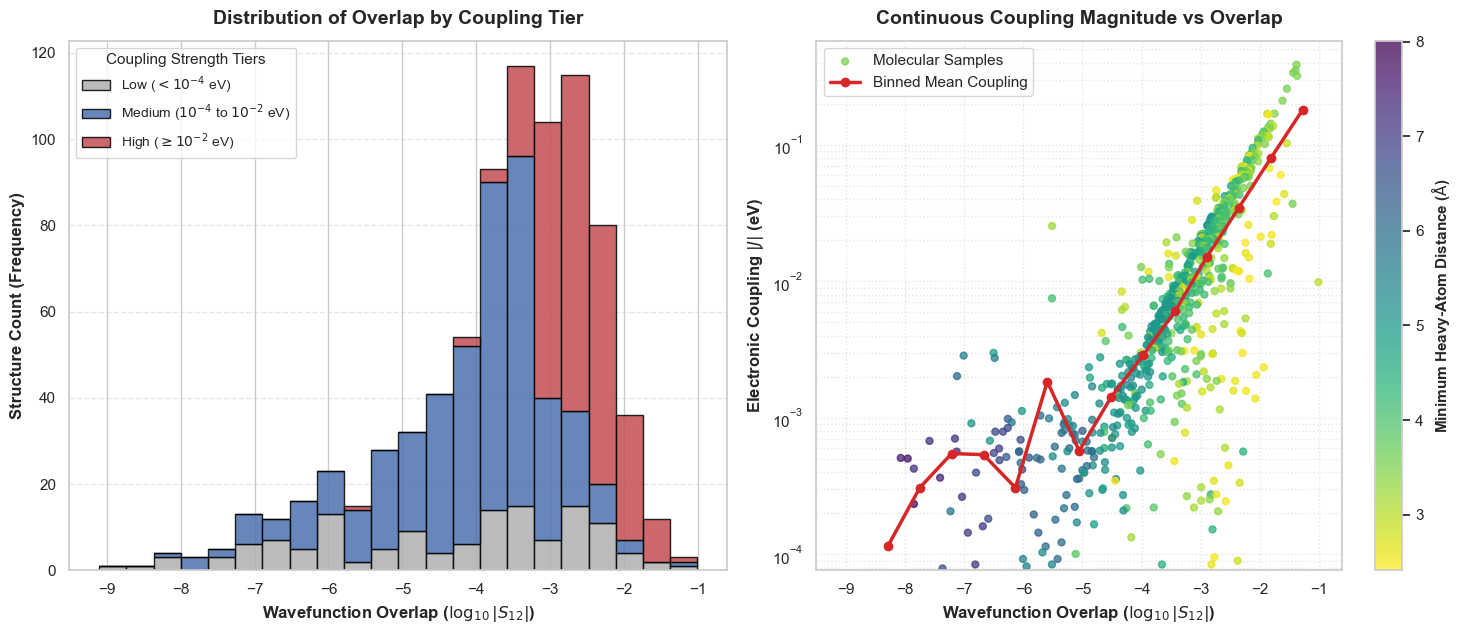

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def plot_binned_overlap_trends(file_path: str, output_image_path: str):
    # 1. Load the dataset
    df = pd.read_csv(file_path)
    
    # 2. Extract absolute value of coupling and create strength tiers
    df['abs_coupling'] = df['Coupling_eV'].abs()
    
    def get_coupling_tier(val):
        if val < 1e-4:
            return 'Low ($< 10^{-4}$ eV)'
        elif val < 1e-2:
            return 'Medium ($10^{-4}$ to $10^{-2}$ eV)'
        else:
            return 'High ($\geq 10^{-2}$ eV)'
            
    df['Coupling_Tier'] = df['abs_coupling'].apply(get_coupling_tier)
    
    # 3. Set up a side-by-side 1x2 plotting panel
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6.5))
    
    # --- PANEL 1: Stacked Histogram of Overlap Tiers ---
    tiers = ['Low ($< 10^{-4}$ eV)', 'Medium ($10^{-4}$ to $10^{-2}$ eV)', 'High ($\geq 10^{-2}$ eV)']
    colors = ['#b0b0b0', '#4C72B0', '#C44E52']  # Gray, Blue, Red
    
    # Isolate overlap arrays for each tier
    hist_data = [df[df['Coupling_Tier'] == t]['log_abs_S12' if 'log_abs_S12' in df.columns else 'log_absS12'] for t in tiers]
    
    ax1.hist(hist_data, bins=22, stacked=True, color=colors, label=tiers, edgecolor='black', alpha=0.85)
    ax1.set_xlabel('Wavefunction Overlap ($\log_{10}|S_{12}|$)', fontsize=12, fontweight='semibold')
    ax1.set_ylabel('Structure Count (Frequency)', fontsize=12, fontweight='semibold')
    ax1.set_title('Distribution of Overlap by Coupling Tier', fontsize=14, fontweight='bold', pad=12)
    ax1.legend(title='Coupling Strength Tiers', fontsize=10, title_fontsize=11, loc='upper left')
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    
    # --- PANEL 2: Clean Overlap vs Coupling Scatter with Distance Overlay ---
    overlap_col = 'log_abs_S12' if 'log_abs_S12' in df.columns else 'log_absS12'
    distance_col = 'Min_HeavyDist_Ang'
    
    # Calculate a running binned average trend line
    bins = np.linspace(df[overlap_col].min(), df[overlap_col].max(), 16)
    df['bin'] = pd.cut(df[overlap_col], bins=bins)
    bin_centers = 0.5 * (bins[:-1] + bins[1:])
    bin_means = df.groupby('bin', observed=False)['abs_coupling'].mean()
    
    # Plot individual structures color-coded by closest heavy-atom distance
    # viridis_r reverses the colormap so that close contact (small distance) is highlighted vibrantly
    sc = ax2.scatter(df[overlap_col], df['abs_coupling'], c=df[distance_col], 
                    cmap='viridis_r', s=25, alpha=0.75, label='Molecular Samples')
    
    # Superimpose the binned trend line
    ax2.plot(bin_centers, bin_means, color='#d62728', marker='o', linewidth=2.5, 
             linestyle='-', label='Binned Mean Coupling')
    
    # Format axes
    ax2.set_yscale('log')  # Log scale perfectly handles multi-order magnitude coupling decay
    ax2.set_xlabel('Wavefunction Overlap ($\log_{10}|S_{12}|$)', fontsize=12, fontweight='semibold')
    ax2.set_ylabel('Electronic Coupling $|J|$ (eV)', fontsize=12, fontweight='semibold')
    ax2.set_title('Continuous Coupling Magnitude vs Overlap', fontsize=14, fontweight='bold', pad=12)
    
    # Add a colorbar for distance context
    cbar = fig.colorbar(sc, ax=ax2)
    cbar.set_label('Minimum Heavy-Atom Distance ($\mathrm{\AA}$)', fontsize=11, fontweight='semibold')
    
    ax2.legend(loc='upper left')
    ax2.grid(True, which="both", linestyle=':', alpha=0.5)
    
    # Save the finalized figure
    plt.tight_layout()
    plt.savefig(output_image_path, dpi=300)
    print(f"Success! Distribution and trend plot saved to '{output_image_path}'")

if __name__ == "__main__":
    dataset_path = "../data/808_master_dataset_v2.csv"
    save_path = "Image/overlap_coupling__trends.png"
    plot_binned_overlap_trends(dataset_path, save_path)

In [4]:
# ===============================
# 3. CREATE OUTPUT DIR
# ===============================
plot_dir = "../Figure/distribution_plots"
os.makedirs(plot_dir, exist_ok=True)

In [8]:
#I want to check the ranges of the features before plotting distributions, to ensure they are reasonable and to identify any potential outliers or data issues that could affect the visualizations.
feature_cols = ['dz', 'dx', 'dy', 'cos_theta',
                'cos_4phi', 'sin_4phi', 'cos_4psi', 'sin_4psi',
                'd_lateral', 'cos_4alpha', 'sin_4alpha']

# Show feature ranges
summary = df[feature_cols].describe().round(5).T[['mean', 'std', 'min', 'max']]
print(summary)

               mean      std      min       max
dz          4.78506  1.97895  0.00023   9.93577
dx          3.50081  3.15608 -5.83090  10.21524
dy          1.74953  2.65712 -6.86986   9.99809
cos_theta   0.76151  0.39612 -0.96592   1.00000
cos_4phi    0.46776  0.71688 -1.00000   1.00000
sin_4phi    0.00290  0.51793 -0.99999   1.00000
cos_4psi    0.63709  0.63737 -0.99700   1.00000
sin_4psi    0.03842  0.43260 -0.90231   0.97640
d_lateral   4.92519  2.84062  0.00012  10.21715
cos_4alpha -0.05326  0.87449 -0.99994   0.99997
sin_4alpha  0.11897  0.46850 -0.99997   1.00000


Coupling distribution Analysis

In [23]:
import pandas as pd
import numpy as np

# Load data
df = pd.read_csv("../data/808_master_dataset_v2.csv")

# Total number of couplings (you expect 808)
total = len(df)
print("Total rows:", total)

# Use absolute value of Coupling_eV for binning
c = df["Coupling_eV"].abs()

# Define bins and labels
bins = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, np.inf]
labels = [
    "(0, 1e-4)",
    "[1e-4, 1e-3)",
    "[1e-3, 1e-2)",
    "[1e-2, 1e-1)",
    "[1e-1, inf)"
]

# Special handling for exactly 0
is_zero = (c == 0.0)

# Bin non-zero values
ranges = pd.cut(c[~is_zero], bins=bins, labels=labels, right=False)

# Count per range
counts = ranges.value_counts().sort_index()

# Build summary table
summary = pd.DataFrame({
    "Coupling_range": ["0"] + labels,
    "Count": [is_zero.sum()] + [counts.get(lbl, 0) for lbl in labels]
})

summary["Fraction"] = summary["Count"] / total * 100

print(summary)

Total rows: 808
  Coupling_range  Count   Fraction
0              0     67   8.292079
1      (0, 1e-4)     67   8.292079
2   [1e-4, 1e-3)    130  16.089109
3   [1e-3, 1e-2)    275  34.034653
4   [1e-2, 1e-1)    244  30.198020
5    [1e-1, inf)     25   3.094059


Random Forest Classifier test

In [24]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report

# --- Load data ---
df = pd.read_csv("../data/808_master_dataset_v2.csv")

# --- Define columns ---
feature_cols = ["Coupling_eV", "log10_J_cdft", "FeFe_Dist_Ang", "NN_Dist_1_Ang",
                "Min_HeavyDist_Ang", "dz", "dx", "dy", "cos_theta",
                "cos_4phi", "sin_4phi", "cos_4psi", "sin_4psi",
                "d_lateral", "cos_4alpha", "sin_4alpha",
                "S12_sq", "log_absS12", "absS12"]

# Inputs for ML (do NOT include the targets as features)
X_cols = ["FeFe_Dist_Ang", "NN_Dist_1_Ang", "Min_HeavyDist_Ang",
          "dz", "dx", "dy", "cos_theta",
          "cos_4phi", "sin_4phi", "cos_4psi", "sin_4psi",
          "d_lateral", "cos_4alpha", "sin_4alpha",
          "S12_sq", "log_absS12", "absS12"]

target_col = "log10_J_cdft"

# --- Clean: drop rows missing target or features ---
df = df.dropna(subset=[target_col] + X_cols)

# --- Build classification label: large (>= -4) vs small (< -4) ---
threshold = -4.0
df["y_class"] = (df[target_col] >= threshold).astype(int)  # 1: large, 0: small

X = df[X_cols]
y_class = df["y_class"]

# --- Train/test split for classifier ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y_class, test_size=0.2, stratify=y_class, random_state=42
)

# --- Classifier: Random Forest (no scaling needed here) ---
clf = RandomForestClassifier(
    n_estimators=300,
    random_state=0,
    class_weight="balanced"  # helpful if classes are imbalanced
)
clf.fit(X_train, y_train)

# Evaluate classifier
y_pred = clf.predict(X_test)
print(classification_report(y_test, y_pred))

# Feature importances for classification
importances = pd.Series(clf.feature_importances_, index=X_cols).sort_values(ascending=False)
print("Classifier feature importances:")
print(importances)

# --- Prepare data for KRR regression: only LARGE couplings ---
df_large = df[df["y_class"] == 1].copy()
X_large = df_large[X_cols]
y_reg = df_large[target_col]

# Train/test split for regression on large couplings
Xtr_r, Xte_r, ytr_r, yte_r = train_test_split(
    X_large, y_reg, test_size=0.2, random_state=0
)

# --- KRR pipeline (scaling + kernel ridge regression) ---
krr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("krr", KernelRidge(kernel="rbf", alpha=1.0, gamma=0.1))
])

krr_model.fit(Xtr_r, ytr_r)

# Simple evaluation on test set (R^2 and MAE)
from sklearn.metrics import r2_score, mean_absolute_error

y_pred_r = krr_model.predict(Xte_r)
print("KRR on large couplings:")
print("R^2:", r2_score(yte_r, y_pred_r))
print("MAE:", mean_absolute_error(yte_r, y_pred_r))

              precision    recall  f1-score   support

           0       0.50      0.08      0.13        13
           1       0.92      0.99      0.95       136

    accuracy                           0.91       149
   macro avg       0.71      0.53      0.54       149
weighted avg       0.88      0.91      0.88       149

Classifier feature importances:
Min_HeavyDist_Ang    0.102154
cos_4phi             0.099825
cos_4psi             0.098375
log_absS12           0.092124
cos_theta            0.080521
absS12               0.078846
dz                   0.066015
sin_4psi             0.049223
sin_4alpha           0.049031
NN_Dist_1_Ang        0.048839
cos_4alpha           0.047127
dx                   0.045232
dy                   0.039830
sin_4phi             0.036496
FeFe_Dist_Ang        0.026518
d_lateral            0.026035
S12_sq               0.013810
dtype: float64
KRR on large couplings:
R^2: 0.4195538610151499
MAE: 0.3589497673105883
